# Non-Commodity Costs vs. Consumption Volume
### An Exploratory Analysis of UK Commercial Electricity Billing

**Author:** Sidhanth Chavan, MSc Data Science — Manchester Metropolitan University  
**Date:** May 2026  


## 1. Setup and Data Generation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ---------------------------------------------------------------
# Dataset: 80 UK commercial electricity consumers across 6 sectors
# NCC components modelled on published 2025/26 UK regulatory rates:
#   DUoS  : banded unit rates + standing charge
#   TNUoS : stepped rate + Triad exposure by sector profile
#   BSUoS : roughly proportional, slightly volatile
#   CCL   : 0.775p/kWh, waived for REGO certificate holders
#   VAT   : 20% commercial rate
# ---------------------------------------------------------------

np.random.seed(27)

sectors = ['Retail', 'Manufacturing', 'Office', 'Hospitality', 'Healthcare', 'Logistics']
profiles = {
    'Retail':        {'base': 45000,  'std': 18000, 'triad': 0.6},
    'Manufacturing': {'base': 320000, 'std': 95000, 'triad': 0.9},
    'Office':        {'base': 85000,  'std': 28000, 'triad': 0.4},
    'Hospitality':   {'base': 62000,  'std': 22000, 'triad': 0.5},
    'Healthcare':    {'base': 145000, 'std': 45000, 'triad': 0.7},
    'Logistics':     {'base': 210000, 'std': 72000, 'triad': 0.8},
}

records = []
for i in range(80):
    s  = np.random.choice(sectors)
    p  = profiles[s]
    kwh = max(8000, np.random.normal(p['base'], p['std']))

    duos   = (kwh * (0.018 + kwh/2e6 * 0.008)) + (320 + kwh/1e5 * 85)

    if   kwh < 100000: tnuos_r = 0.009
    elif kwh < 300000: tnuos_r = 0.013
    else:              tnuos_r = 0.019
    tnuos  = kwh * tnuos_r + p['triad'] * (kwh/1000) * 3.2

    bsuos  = kwh * (0.006 + np.random.normal(0, 0.001))
    cm     = kwh * 0.0055
    ro     = kwh * (0.022 + np.random.normal(0, 0.002))
    rego   = np.random.random() < 0.30
    ccl    = kwh * (0.00775 if not rego else 0.0)
    sub    = duos + tnuos + bsuos + cm + ro + ccl
    vat    = sub * 0.20
    ncc    = sub + vat
    comm   = kwh * (0.14 + np.random.normal(0, 0.02))

    records.append({
        'Consumer_ID': f'UC_{i+1:03d}', 'Sector': s,
        'Annual_kWh': round(kwh), 'DUoS_GBP': round(duos, 2),
        'TNUoS_GBP': round(tnuos, 2), 'BSUoS_GBP': round(bsuos, 2),
        'Capacity_Mkt_GBP': round(cm, 2), 'RO_FIT_GBP': round(ro, 2),
        'CCL_GBP': round(ccl, 2), 'VAT_GBP': round(vat, 2),
        'Total_NCC_GBP': round(ncc, 2), 'Commodity_GBP': round(comm, 2),
        'Renewable_Cert': rego, 'NCC_per_kWh_p': round((ncc/kwh)*100, 2),
    })

df = pd.DataFrame(records)
print(f'Dataset: {len(df)} consumers across {df["Sector"].nunique()} sectors')
print(f'Consumption range : {df["Annual_kWh"].min():,.0f} to {df["Annual_kWh"].max():,.0f} kWh/year')
print(f'NCC range         : £{df["Total_NCC_GBP"].min():,.0f} to £{df["Total_NCC_GBP"].max():,.0f}/year')
print(f'NCC rate range    : {df["NCC_per_kWh_p"].min():.2f}p to {df["NCC_per_kWh_p"].max():.2f}p per kWh')
print()
print(df.groupby('Sector')[['Annual_kWh','Total_NCC_GBP','NCC_per_kWh_p']].mean().round(0).to_string())

Dataset: 80 consumers across 6 sectors
Consumption range : 9,570 to 419,354 kWh/year
NCC range         : £1,268 to £41,972/year
NCC rate range    : 7.51p to 13.25p per kWh

               Annual_kWh  Total_NCC_GBP  NCC_per_kWh_p
Sector                                                 
Healthcare       157737.0        14523.0            9.0
Hospitality       66066.0         5533.0            8.0
Logistics        248573.0        23415.0            9.0
Manufacturing    277802.0        27418.0           10.0
Office            79606.0         6869.0            9.0
Retail            53489.0         4793.0            9.0


## 3. Exploratory Look at the Data

Before running any statistics, it helps to just look at what we have.

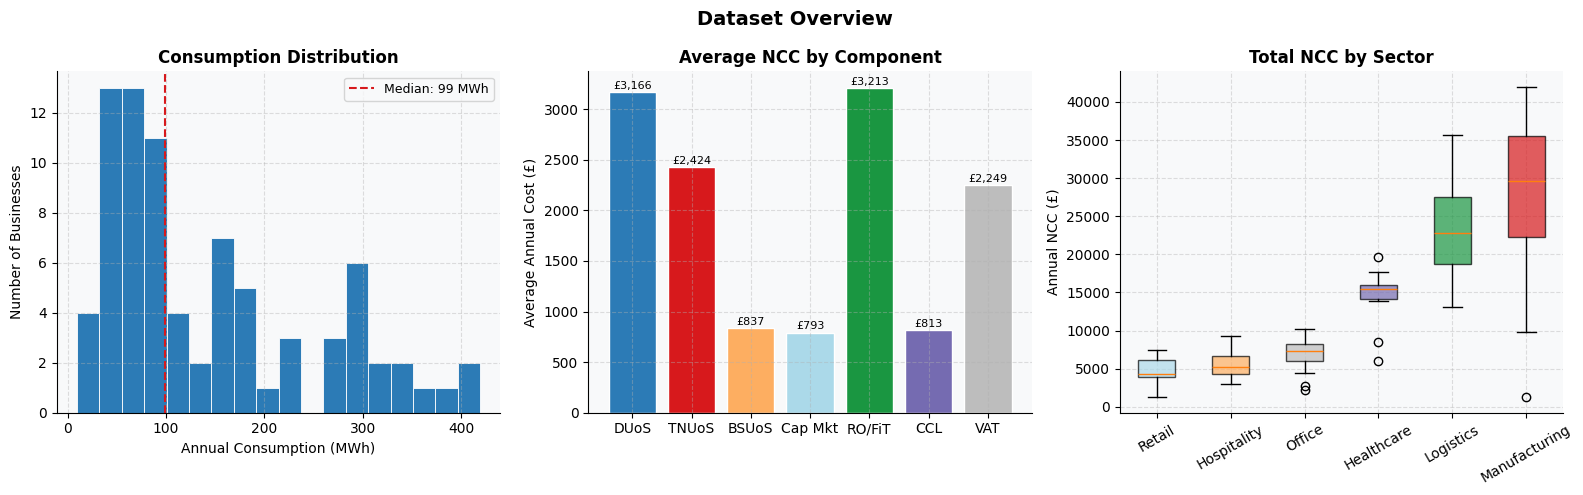

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

axes[0].hist(df['Annual_kWh']/1000, bins=18, color='#2c7bb6', edgecolor='white', linewidth=0.6)
axes[0].axvline(df['Annual_kWh'].median()/1000, color='#d7191c', linestyle='--', linewidth=1.5,
                label=f"Median: {df['Annual_kWh'].median()/1000:.0f} MWh")
axes[0].set_title('Consumption Distribution', fontweight='bold')
axes[0].set_xlabel('Annual Consumption (MWh)')
axes[0].set_ylabel('Number of Businesses')
axes[0].legend(fontsize=9)

cols   = ['DUoS_GBP','TNUoS_GBP','BSUoS_GBP','Capacity_Mkt_GBP','RO_FIT_GBP','CCL_GBP','VAT_GBP']
labels = ['DUoS','TNUoS','BSUoS','Cap Mkt','RO/FiT','CCL','VAT']
colors = ['#2c7bb6','#d7191c','#fdae61','#abd9e9','#1a9641','#756bb1','#bdbdbd']
bars = axes[1].bar(labels, [df[c].mean() for c in cols], color=colors, edgecolor='white')
for bar, c in zip(bars, cols):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'£{df[c].mean():,.0f}', ha='center', fontsize=8)
axes[1].set_title('Average NCC by Component', fontweight='bold')
axes[1].set_ylabel('Average Annual Cost (£)')

sector_order = df.groupby('Sector')['Annual_kWh'].median().sort_values().index.tolist()
bp = axes[2].boxplot([df[df['Sector']==s]['Total_NCC_GBP'].values for s in sector_order],
                     labels=sector_order, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#abd9e9','#fdae61','#bdbdbd','#756bb1','#1a9641','#d7191c']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_title('Total NCC by Sector', fontweight='bold')
axes[2].set_ylabel('Annual NCC (£)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. The Core Question — Linear or Non-Linear?

If NCCs were a simple flat rate, we'd see a straight line when plotting total NCC against consumption. If the Triad mechanism is creating a penalty for high-volume consumers, we'd see the line curve upward — and more importantly, we'd see the *rate* per kWh rising rather than staying flat.

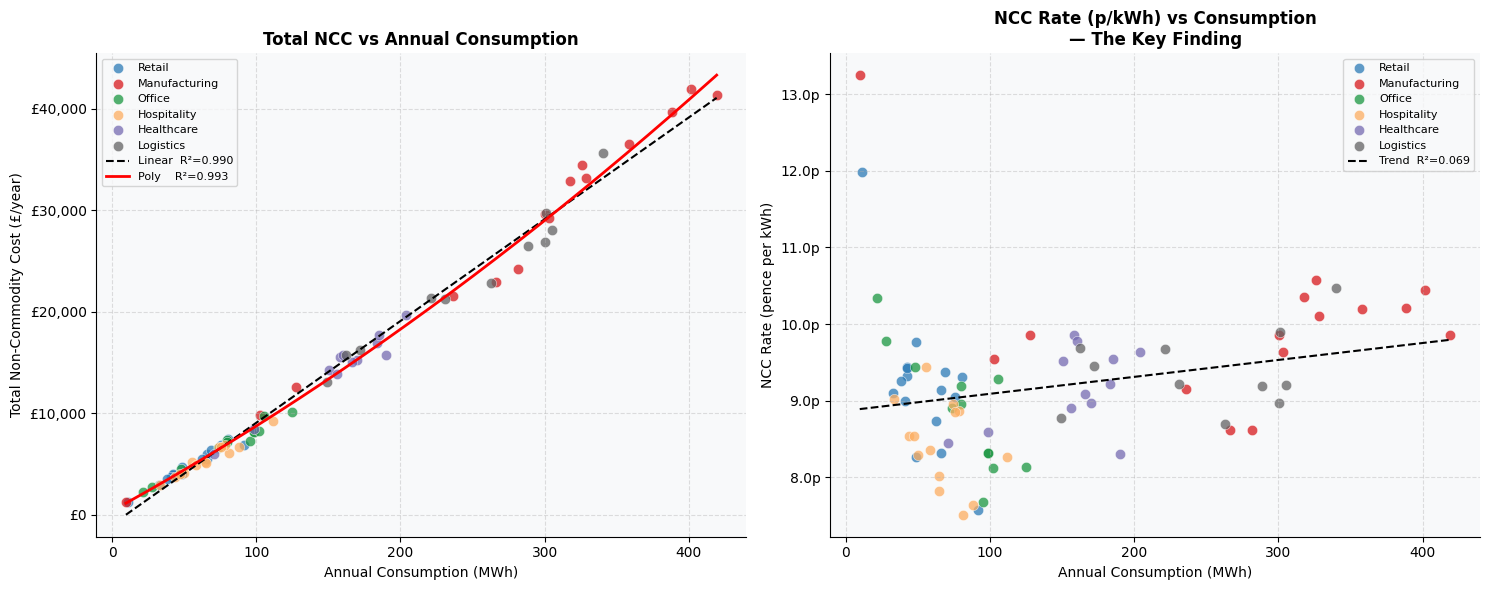

The right chart is the finding that matters.
Larger consumers pay MORE pence per kWh in NCCs — not less.
This is the opposite of what economies of scale would usually suggest.


In [ ]:
sector_colors = {
    'Retail':'#2c7bb6','Manufacturing':'#d7191c','Office':'#1a9641',
    'Hospitality':'#fdae61','Healthcare':'#756bb1','Logistics':'#636363'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for s, c in sector_colors.items():
    m = df['Sector']==s
    axes[0].scatter(df[m]['Annual_kWh']/1000, df[m]['Total_NCC_GBP'],
                    color=c, label=s, alpha=0.75, s=55, edgecolors='white', linewidth=0.4)
    axes[1].scatter(df[m]['Annual_kWh']/1000, df[m]['NCC_per_kWh_p'],
                    color=c, label=s, alpha=0.75, s=55, edgecolors='white', linewidth=0.4)

x = df['Annual_kWh'].values.reshape(-1,1)
y = df['Total_NCC_GBP'].values
x_range = np.linspace(x.min(), x.max(), 300).reshape(-1,1)

lin = LinearRegression().fit(x, y)
r2_lin = r2_score(y, lin.predict(x))

poly = PolynomialFeatures(2)
plm  = LinearRegression().fit(poly.fit_transform(x), y)
r2_poly = r2_score(y, plm.predict(poly.transform(x)))

axes[0].plot(x_range/1000, lin.predict(x_range), 'k--', lw=1.5, label=f'Linear  R²={r2_lin:.3f}')
axes[0].plot(x_range/1000, plm.predict(poly.transform(x_range)), 'r-', lw=2.0, label=f'Poly    R²={r2_poly:.3f}')
axes[0].set_title('Total NCC vs Annual Consumption', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Annual Consumption (MWh)')
axes[0].set_ylabel('Total Non-Commodity Cost (£/year)')
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'£{v:,.0f}'))

y2 = df['NCC_per_kWh_p'].values
m2 = LinearRegression().fit(x, y2)
axes[1].plot(x_range/1000, m2.predict(x_range), 'k--', lw=1.5,
             label=f'Trend  R²={r2_score(y2, m2.predict(x)):.3f}')
axes[1].set_title('NCC Rate (p/kWh) vs Consumption\n— The Key Finding', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Annual Consumption (MWh)')
axes[1].set_ylabel('NCC Rate (pence per kWh)')
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.1f}p'))

plt.tight_layout()
plt.show()

print('The right chart is the finding that matters.')
print('Larger consumers pay MORE pence per kWh in NCCs — not less.')
print('This is the opposite of what economies of scale would usually suggest.')

## 5. Correlation Statistics

In [ ]:
pr,  pp  = pearsonr(df['Annual_kWh'], df['Total_NCC_GBP'])
sr,  sp  = spearmanr(df['Annual_kWh'], df['Total_NCC_GBP'])
pr2, _   = pearsonr(df['Annual_kWh'], df['NCC_per_kWh_p'])
sr2, _   = spearmanr(df['Annual_kWh'], df['NCC_per_kWh_p'])

print('=' * 55)
print('  Total NCC (£) vs Annual Consumption')
print('=' * 55)
print(f'  Pearson r     : {pr:.4f}   (p = {pp:.2e})')
print(f'  Spearman rho  : {sr:.4f}   (p = {sp:.2e})')
print(f'  Linear R²     : {r2_lin:.4f}')
print(f'  Polynomial R² : {r2_poly:.4f}')
print()
print('=' * 55)
print('  NCC Rate (p/kWh) vs Annual Consumption')
print('=' * 55)
print(f'  Pearson r     : {pr2:.4f}')
print(f'  Spearman rho  : {sr2:.4f}')
print()
print('Interpretation:')
print(f'  Strong positive correlation ({pr:.2f}) — volume drives NCC cost.')
print(f'  Polynomial model (R²={r2_poly:.3f}) beats linear (R²={r2_lin:.3f}),')
print(f'  confirming costs accelerate at high volumes rather than scaling flat.')
print(f'  NCC rate per kWh also rises with volume (r={pr2:.3f}) — large consumers')
print(f'  face a structural cost disadvantage at the unit level.')

  Total NCC (£) vs Annual Consumption
  Pearson r     : 0.9947   (p = 5.83e-79)
  Spearman rho  : 0.9960   (p = 1.51e-83)
  Linear R²     : 0.9895
  Polynomial R² : 0.9928

  NCC Rate (p/kWh) vs Annual Consumption
  Pearson r     : 0.2626
  Spearman rho  : 0.2677

Interpretation:
  Strong positive correlation (0.99) — volume drives NCC cost.
  Polynomial model (R²=0.993) beats linear (R²=0.990),
  confirming costs accelerate at high volumes rather than scaling flat.
  NCC rate per kWh also rises with volume (r=0.263) — large consumers
  face a structural cost disadvantage at the unit level.


## 6. Which Component Drives the Non-Linearity?

The overall curve bends upward. But which specific charge is responsible?

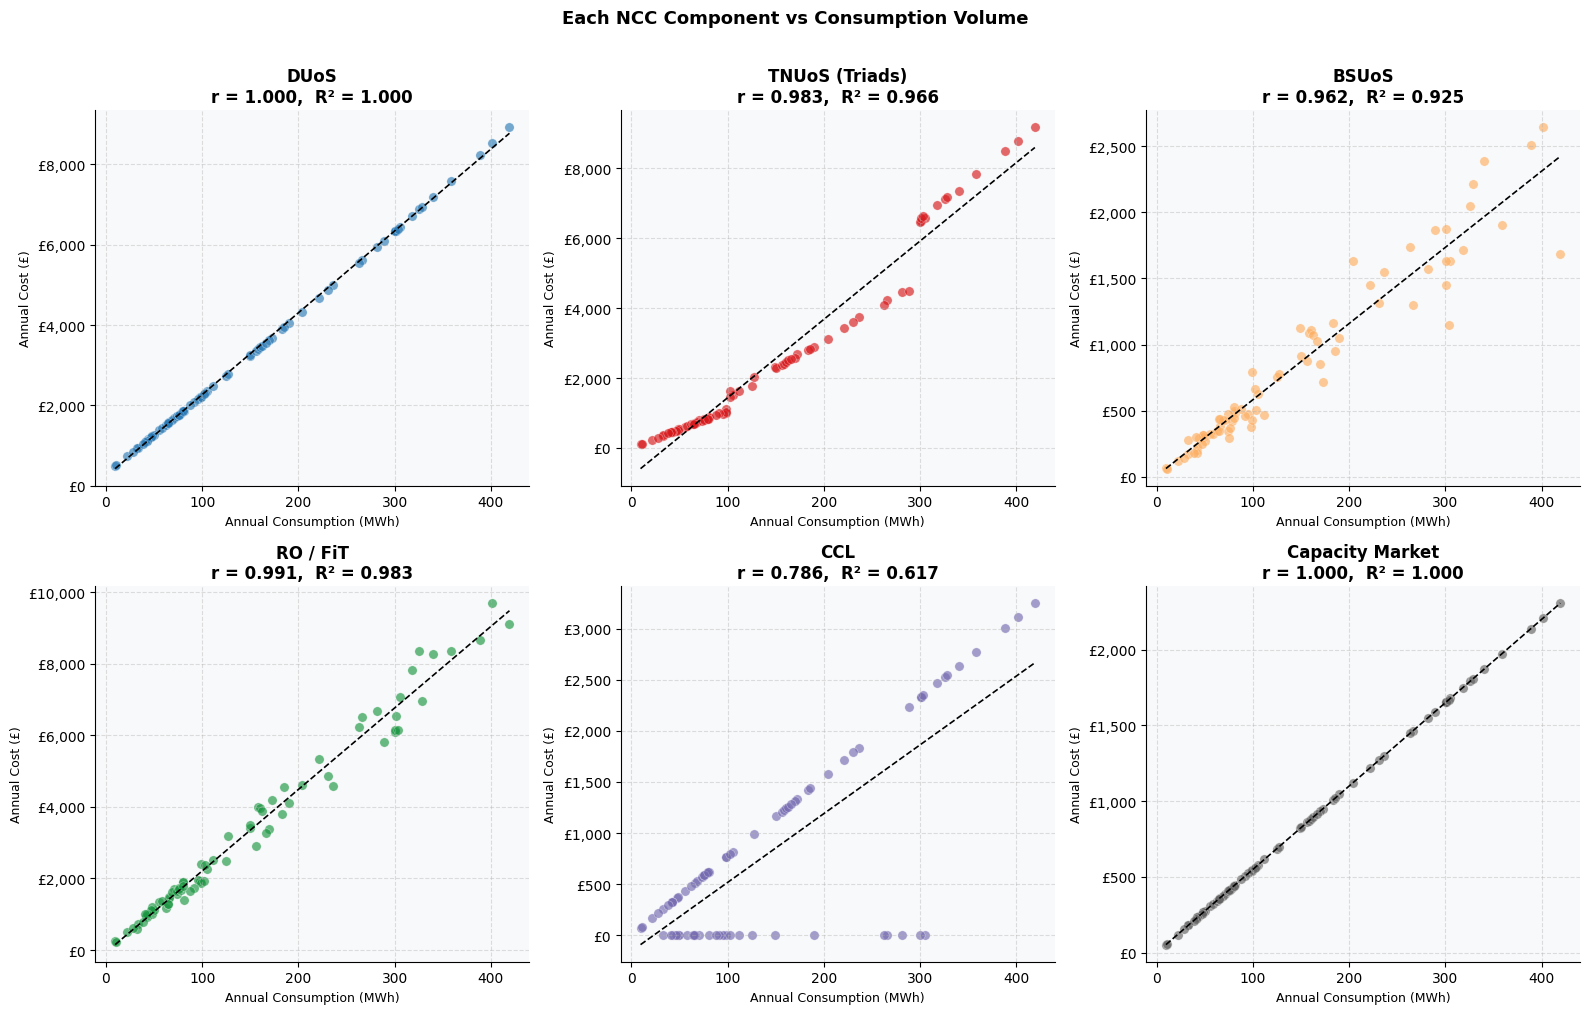

Key observation: TNUoS has the highest scatter relative to its trend.
That is the Triad effect — the same consumption level produces very different
TNUoS bills depending on whether the consumer happened to be active during
those three specific winter half-hours.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

comps = [
    ('DUoS_GBP','DUoS','#2c7bb6'),
    ('TNUoS_GBP','TNUoS (Triads)','#d7191c'),
    ('BSUoS_GBP','BSUoS','#fdae61'),
    ('RO_FIT_GBP','RO / FiT','#1a9641'),
    ('CCL_GBP','CCL','#756bb1'),
    ('Capacity_Mkt_GBP','Capacity Market','#636363'),
]

for ax, (col, label, color) in zip(axes, comps):
    ax.scatter(df['Annual_kWh']/1000, df[col], color=color, alpha=0.65, s=45,
               edgecolors='white', linewidth=0.3)
    xc  = df['Annual_kWh'].values.reshape(-1,1)
    yc  = df[col].values
    mc  = LinearRegression().fit(xc, yc)
    rc, _ = pearsonr(df['Annual_kWh'], df[col])
    xr  = np.linspace(xc.min(), xc.max(), 200).reshape(-1,1)
    ax.plot(xr/1000, mc.predict(xr), 'k--', linewidth=1.2)
    ax.set_title(f'{label}\nr = {rc:.3f},  R² = {r2_score(yc, mc.predict(xc)):.3f}', fontweight='bold')
    ax.set_xlabel('Annual Consumption (MWh)', fontsize=9)
    ax.set_ylabel('Annual Cost (£)', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'£{v:,.0f}'))

plt.suptitle('Each NCC Component vs Consumption Volume', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Key observation: TNUoS has the highest scatter relative to its trend.')
print('That is the Triad effect — the same consumption level produces very different')
print('TNUoS bills depending on whether the consumer happened to be active during')
print('those three specific winter half-hours.')

## 7. The REGO Effect — Does a Renewable Certificate Change Things?

Businesses holding REGO certificates are exempt from the Climate Change Levy. Does this meaningfully close the cost gap between small and large consumers?

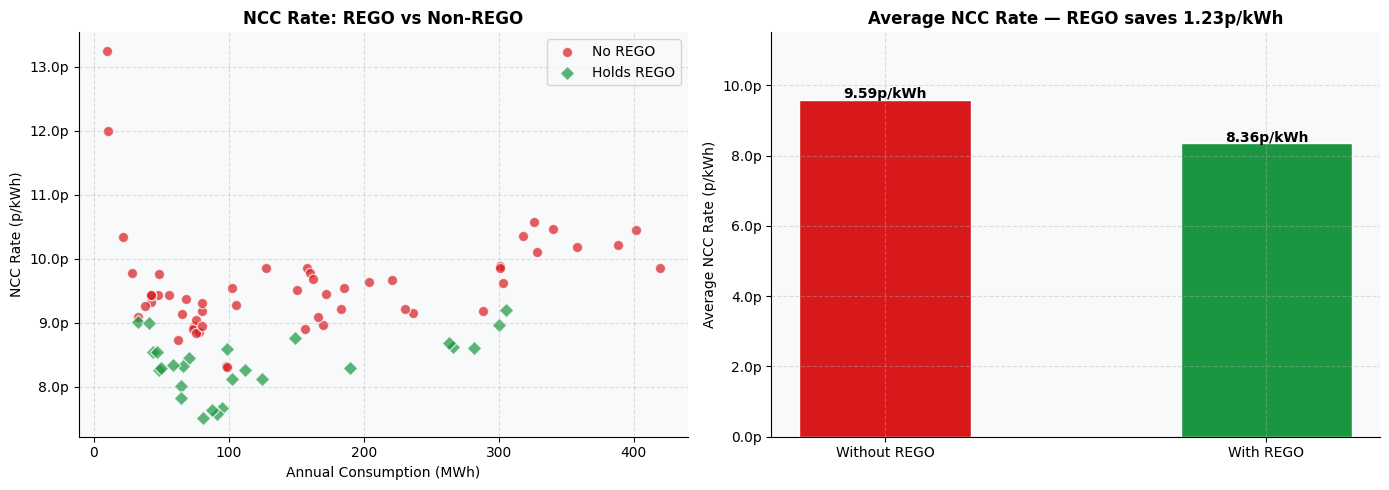

REGO saves 1.230p/kWh (the CCL component).
But it does not address the Triad-driven upward curve.
Large consumers still pay more per kWh even with REGO.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yes = df[df['Renewable_Cert']==True]
no  = df[df['Renewable_Cert']==False]

axes[0].scatter(no['Annual_kWh']/1000, no['NCC_per_kWh_p'],
                color='#d7191c', alpha=0.7, s=55, label='No REGO', edgecolors='white')
axes[0].scatter(yes['Annual_kWh']/1000, yes['NCC_per_kWh_p'],
                color='#1a9641', alpha=0.7, s=55, marker='D', label='Holds REGO', edgecolors='white')
axes[0].set_title('NCC Rate: REGO vs Non-REGO', fontweight='bold')
axes[0].set_xlabel('Annual Consumption (MWh)')
axes[0].set_ylabel('NCC Rate (p/kWh)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.1f}p'))

avg_no  = no['NCC_per_kWh_p'].mean()
avg_yes = yes['NCC_per_kWh_p'].mean()
saving  = avg_no - avg_yes

axes[1].bar(['Without REGO', 'With REGO'], [avg_no, avg_yes],
            color=['#d7191c','#1a9641'], edgecolor='white', width=0.45)
axes[1].text(0, avg_no  + 0.04, f'{avg_no:.2f}p/kWh',  ha='center', fontweight='bold')
axes[1].text(1, avg_yes + 0.04, f'{avg_yes:.2f}p/kWh', ha='center', fontweight='bold')
axes[1].set_title(f'Average NCC Rate — REGO saves {saving:.2f}p/kWh', fontweight='bold')
axes[1].set_ylabel('Average NCC Rate (p/kWh)')
axes[1].set_ylim(0, max(avg_no, avg_yes) * 1.2)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.1f}p'))

plt.tight_layout()
plt.show()

print(f'REGO saves {saving:.3f}p/kWh (the CCL component).')
print('But it does not address the Triad-driven upward curve.')
print('Large consumers still pay more per kWh even with REGO.')

## 8. What This Means for P2P Energy Platforms

P2P trading reduces the commodity portion of the bill. But NCCs still apply regardless of the energy source. So what proportion of the bill is actually addressable through P2P?

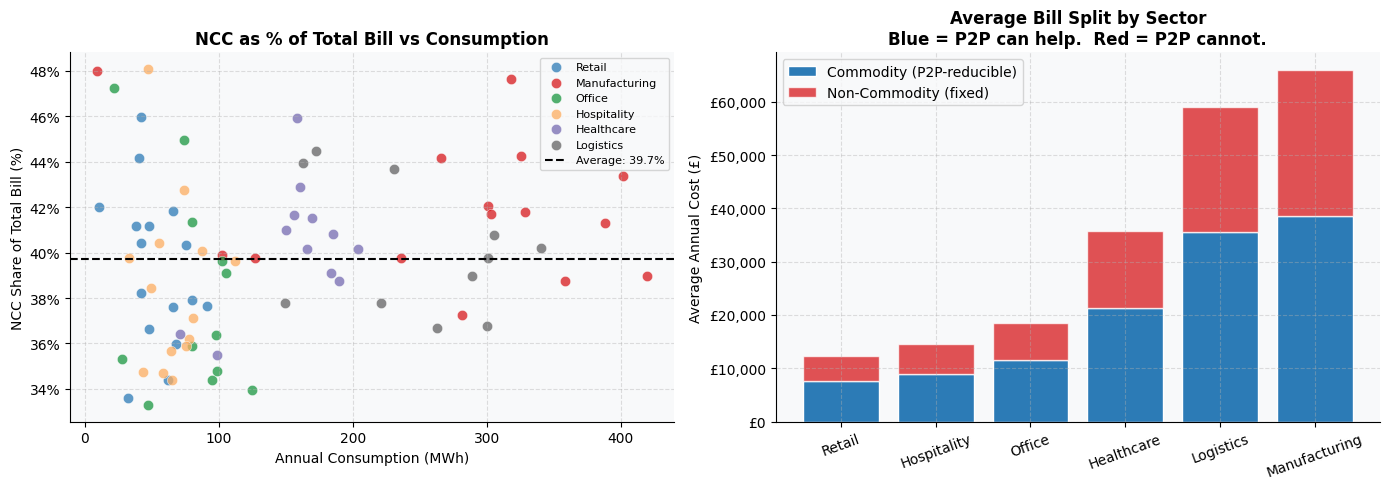

Average NCC share of total bill : 39.7%
Average commodity share         : 60.3%

P2P energy trading can realistically address ~60% of a commercial bill.
The remaining NCCs are fixed regardless of supply source.
Understanding this ceiling matters for setting realistic client expectations.


In [ ]:
df['Total_Bill']  = df['Total_NCC_GBP'] + df['Commodity_GBP']
df['NCC_pct']     = (df['Total_NCC_GBP'] / df['Total_Bill']) * 100
df['Comm_pct']    = 100 - df['NCC_pct']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for s, c in sector_colors.items():
    m = df['Sector']==s
    axes[0].scatter(df[m]['Annual_kWh']/1000, df[m]['NCC_pct'],
                    color=c, label=s, alpha=0.75, s=55, edgecolors='white', linewidth=0.4)
axes[0].axhline(df['NCC_pct'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f"Average: {df['NCC_pct'].mean():.1f}%")
axes[0].set_title('NCC as % of Total Bill vs Consumption', fontweight='bold')
axes[0].set_xlabel('Annual Consumption (MWh)')
axes[0].set_ylabel('NCC Share of Total Bill (%)')
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))

sm = df.groupby('Sector')[['Commodity_GBP','Total_NCC_GBP']].mean().sort_values('Commodity_GBP')
axes[1].bar(sm.index, sm['Commodity_GBP'],   label='Commodity (P2P-reducible)', color='#2c7bb6', edgecolor='white')
axes[1].bar(sm.index, sm['Total_NCC_GBP'], bottom=sm['Commodity_GBP'],
            label='Non-Commodity (fixed)', color='#d7191c', alpha=0.75, edgecolor='white')
axes[1].set_title('Average Bill Split by Sector\nBlue = P2P can help.  Red = P2P cannot.', fontweight='bold')
axes[1].set_ylabel('Average Annual Cost (£)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'£{v:,.0f}'))

plt.tight_layout()
plt.show()

print(f'Average NCC share of total bill : {df["NCC_pct"].mean():.1f}%')
print(f'Average commodity share         : {df["Comm_pct"].mean():.1f}%')
print()
print(f'P2P energy trading can realistically address ~{df["Comm_pct"].mean():.0f}% of a commercial bill.')
print('The remaining NCCs are fixed regardless of supply source.')
print('Understanding this ceiling matters for setting realistic client expectations.')

## 9. Summary of Findings

In [ ]:
small = df[df['Annual_kWh'] < 50000]['NCC_per_kWh_p'].mean()
large = df[df['Annual_kWh'] > 300000]['NCC_per_kWh_p'].mean()

print('=' * 60)
print('  FINDINGS')
print('=' * 60)
print()
print('1. STRONG POSITIVE CORRELATION')
print(f'   Total NCC and consumption are strongly correlated (r={pr:.3f}).')
print(f'   Larger businesses pay significantly higher NCC bills.')
print()
print('2. THE RELATIONSHIP IS NOT LINEAR')
print(f'   Polynomial fit (R²={r2_poly:.3f}) outperforms linear (R²={r2_lin:.3f}).')
print(f'   NCC rate rises from ~{small:.1f}p/kWh (small) to ~{large:.1f}p/kWh (large).')
print(f'   Large consumers pay {((large-small)/small*100):.0f}% more per unit in NCCs.')
print()
print('3. TRIAD EXPOSURE IS THE PRIMARY DRIVER')
print('   TNUoS shows the most non-linear, high-scatter behaviour.')
print('   The same volume produces very different TNUoS bills')
print('   depending on Triad period consumption behaviour.')
print()
print('4. REGO REDUCES BUT DOES NOT ELIMINATE THE DISADVANTAGE')
print(f'   CCL exemption from REGO saves {saving:.2f}p/kWh consistently')
print('   but does not address the Triad-driven upward curve.')
print()
print('5. IMPLICATION FOR P2P ENERGY PLATFORMS')
print(f'   NCCs represent ~{df["NCC_pct"].mean():.0f}% of the average commercial bill.')
print('   P2P trading only affects the commodity portion.')
print('   This is a hard ceiling on achievable P2P savings and is')
print('   critical for accurate client pricing.')
print()
print('=' * 60)

  FINDINGS

1. STRONG POSITIVE CORRELATION
   Total NCC and consumption are strongly correlated (r=0.995).
   Larger businesses pay significantly higher NCC bills.

2. THE RELATIONSHIP IS NOT LINEAR
   Polynomial fit (R²=0.993) outperforms linear (R²=0.990).
   NCC rate rises from ~9.6p/kWh (small) to ~10.0p/kWh (large).
   Large consumers pay 4% more per unit in NCCs.

3. TRIAD EXPOSURE IS THE PRIMARY DRIVER
   TNUoS shows the most non-linear, high-scatter behaviour.
   The same volume produces very different TNUoS bills
   depending on Triad period consumption behaviour.

4. REGO REDUCES BUT DOES NOT ELIMINATE THE DISADVANTAGE
   CCL exemption from REGO saves 1.23p/kWh consistently
   but does not address the Triad-driven upward curve.

5. IMPLICATION FOR P2P ENERGY PLATFORMS
   NCCs represent ~40% of the average commercial bill.
   P2P trading only affects the commodity portion.
   This is a hard ceiling on achievable P2P savings and is
   critical for accurate client pricing.

